## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization_logreg import LogRegScalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
PREFIX_SAVE_IMAGE = 'images/3_objs'

In [6]:
data = pd.read_csv('dataset/compas_onerace.csv')
data = data.drop('Unnamed: 0', axis=1)

fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning from scikit-learn's LogisticRegression.
# These warnings indicate that the solver did not converge within the
# default number of iterations. In this project we are aware of this 
# behavior but choose not to address it here, as it does not affect 
# the focus of our experiments. Therefore, the warnings are silenced 
# to avoid cluttering the logs and console output.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}

num_objs = 3
objectives_names = ['White', 'Non-White', 'L2 Coef']
results = {}

In [9]:
# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

In [10]:
# Logistic Regression Config for MOO
tol = 10**-30
max_iter = 100

In [11]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(
    num_objs=num_objs,
    X=X_train, 
    y=y_train, 
    fair_feat=fair_feature,
    #tol=tol, max_iter=max_iter
    )
equal.optimize(np.array([1/3, 1/3, 1/3]))

In [12]:
def machine_optimize(method, lb_estimate=0.01):
    w_scalar = LogRegScalarization(
        num_objs=num_objs, 
        X=X_train, 
        y=y_train,
        fair_feat=fair_feature,
        tol=tol,
        max_iter=max_iter, 
        lower_bound_estimate=lb_estimate  # Options: 'zero', 'lipschitz', or a float value
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    'moopt': moopt,
                    'objectives': objs,
                    'models': get_models(moopt),
                    'hypervolume': hypervolume_values
                }

In [13]:
def plot_frontier(method, color='#d73027'):
    title='Loss Trade-offs for White and Non-White Person'
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                subset=equal.objs,
                color=color,
                fontsize=20,
                figsize=(10,7), # (10,10)
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

## MOLA

In [14]:
method = 'mola'
machine_optimize(method=method)

<Figure size 1000x700 with 0 Axes>

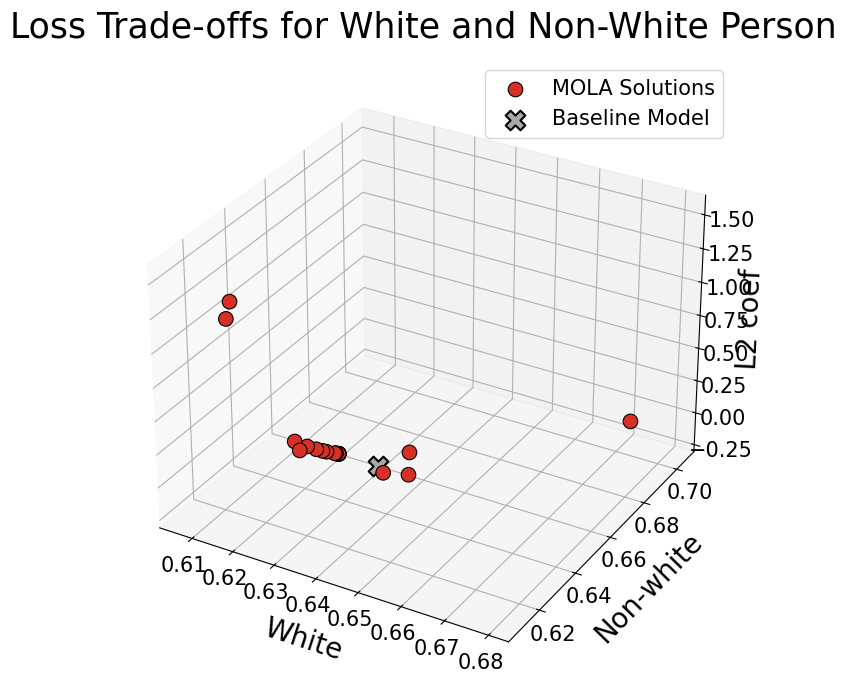

In [15]:
plot_frontier(method, color='#d73027')

### MOLA with gradient

In [16]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


<Figure size 1000x700 with 0 Axes>

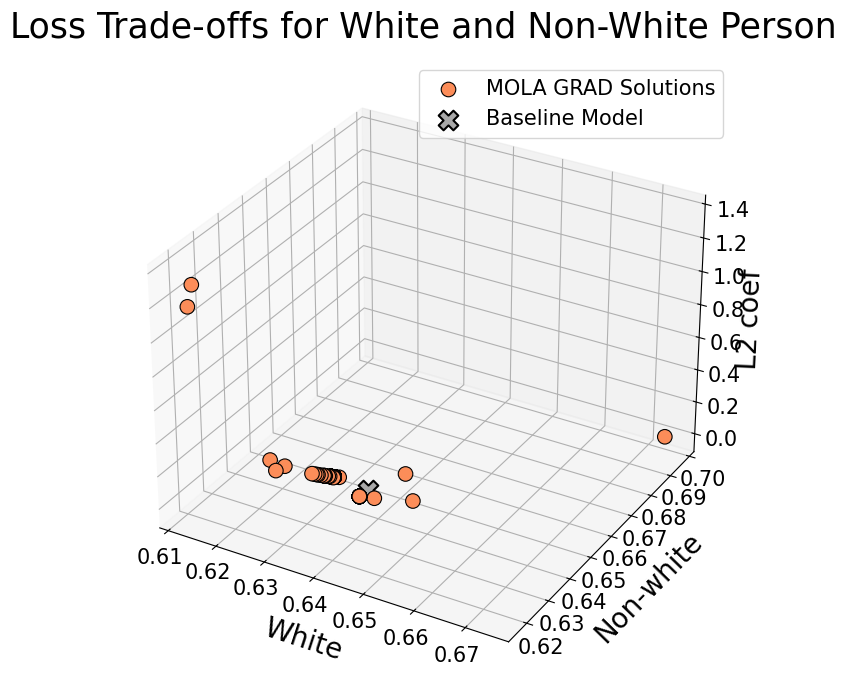

In [17]:
plot_frontier(f'{method}_grad', color='#fc8d59')

### MONISE

In [18]:
method = 'monise'
machine_optimize(method=method)

Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic license - for non-commercial use only - expires 2026-11-06
Set parameter Username
Set parameter LicenseID to value 2733941
Academic lic

### Ramdon Weighted Sum

In [19]:
method = 'random_weights'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [20]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weights']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

In [21]:
monise_solutions = results['monise']['objectives']
nd_indices = NonDominatedSorting().do(monise_solutions, only_non_dominated_front=True)
monise_non_dominated_solutions = monise_solutions[nd_indices]

In [22]:
print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')
print(f'Number of non-dominated solutions with MONISE        : {len(monise_non_dominated_solutions)}')


Number of non-dominated solutions with MOLA          : 28
Number of non-dominated solutions with MOLA GRAD     : 225
Number of non-dominated solutions with RANDOM WEIGHT : 500
Number of non-dominated solutions with MONISE        : 488


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

<Figure size 2000x1800 with 0 Axes>

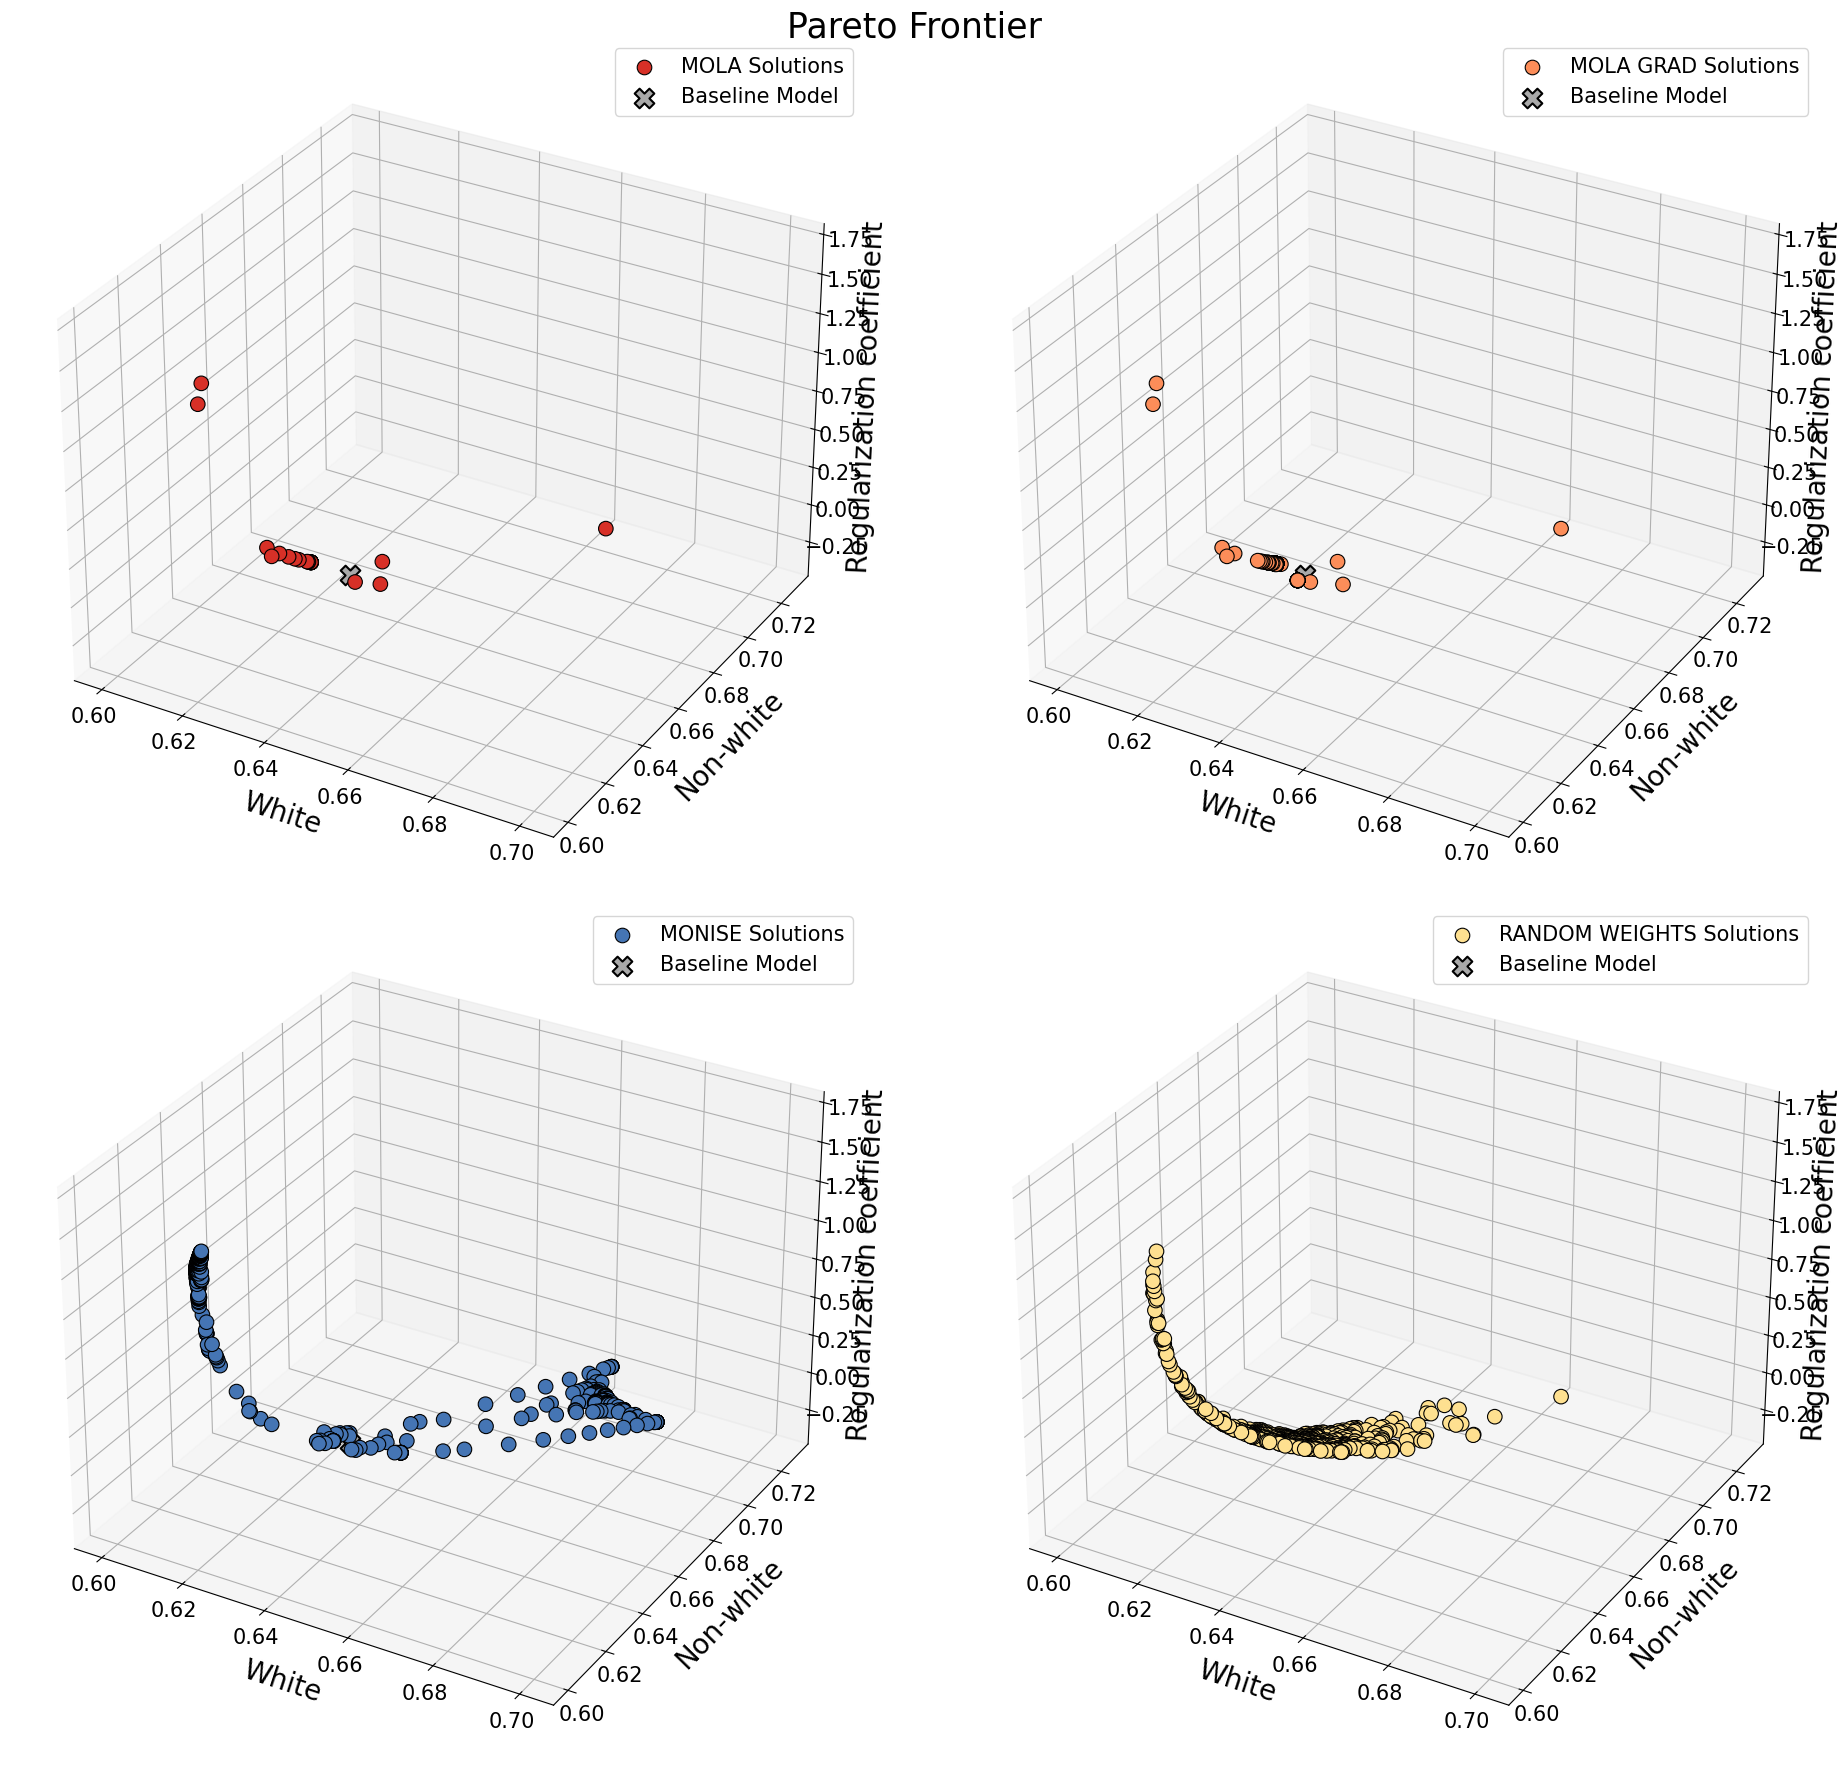

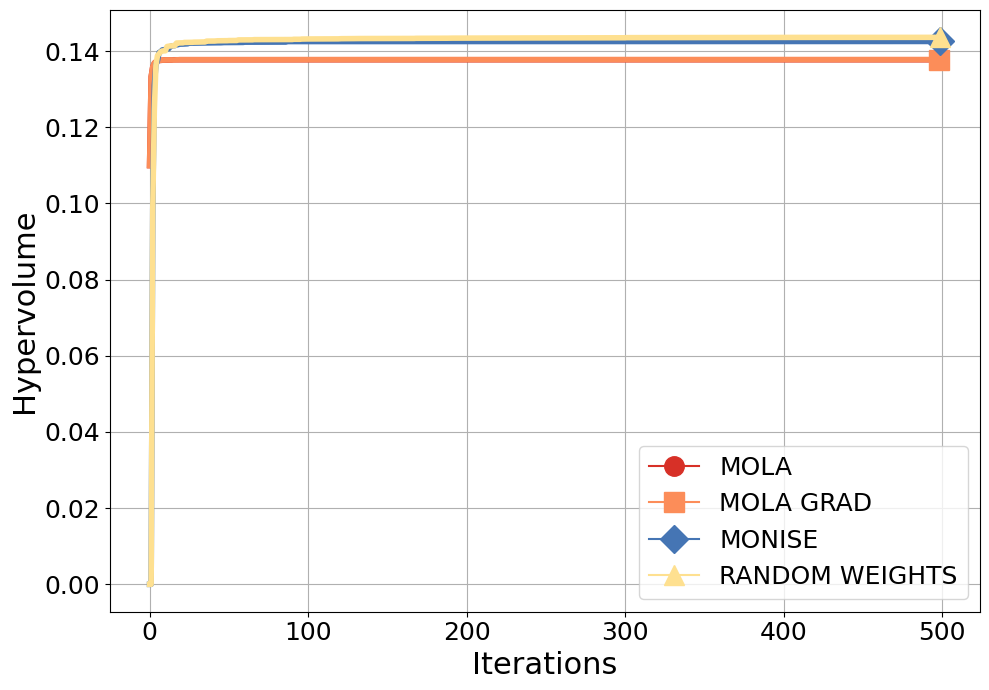

In [23]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions
pareto_dict['monise'] = monise_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

axes_label = ['White', 'Non-White', 'Regularization Coefficient']
plot_pareto(methods=pareto_dict,
               labels=axes_label, 
               #title='Comparative Pareto Frontiers Across MOO Methods',
               subset=equal.objs,
               save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf',
               figsize=(10,9),
               fontsize=20,
               s_factor=2,
               )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')